In [1]:
import os
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from taurex.plot.corner import corner

In [ ]:
BASE_DIR = "./data"
CLUSTER_ID = 89
FILE_ID = 102
PLANET_ID = 0
NUM_PLANETS_TO_PLOT = 50

OUTPUT_DIR = f"{BASE_DIR}/Cluster{CLUSTER_ID}"
RETRIEVAL_FILE_TEMPLATE = f"{OUTPUT_DIR}/{{planet_id}}/RetrievalSolution_{FILE_ID}_{{planet_id}}.pkl"
DATA_FILE_PATH = f"{BASE_DIR}/test_parameters_planet_data_0-99_index_{FILE_ID}_linear.csv"

In [4]:
def plot_single_retrieval():
    file_name = RETRIEVAL_FILE_TEMPLATE.format(planet_id=PLANET_ID)
    
    with open(file_name, "rb") as f:
        solution = pickle.load(f)

    tracedata = solution['solution0']['tracedata'][:]
    weights = solution['solution0']['weights'][:]
    latex_names = list(solution["solution0"]["fit_params"].keys())
    
    n_dim = len(tracedata[0, :])
    fig, ax = plt.subplots(n_dim, n_dim, figsize=(8, 8))
    
    fig = corner(
        xs=tracedata,
        weights=weights,
        labels=latex_names,
        label_kwargs=dict(fontsize=9),
        smooth=True,
        scale_hist=True,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs=dict(fontsize=9),
        hist2d_kwargs=dict(fontsize=9),
        range=[(0.95, 1.05), (400, 1200), (-3, 0), (-3, 0)],
        ret=True,
        fill_contours=True,
        color='skyblue',
        top_ticks=False,
        fig=fig
    )
    plt.show()

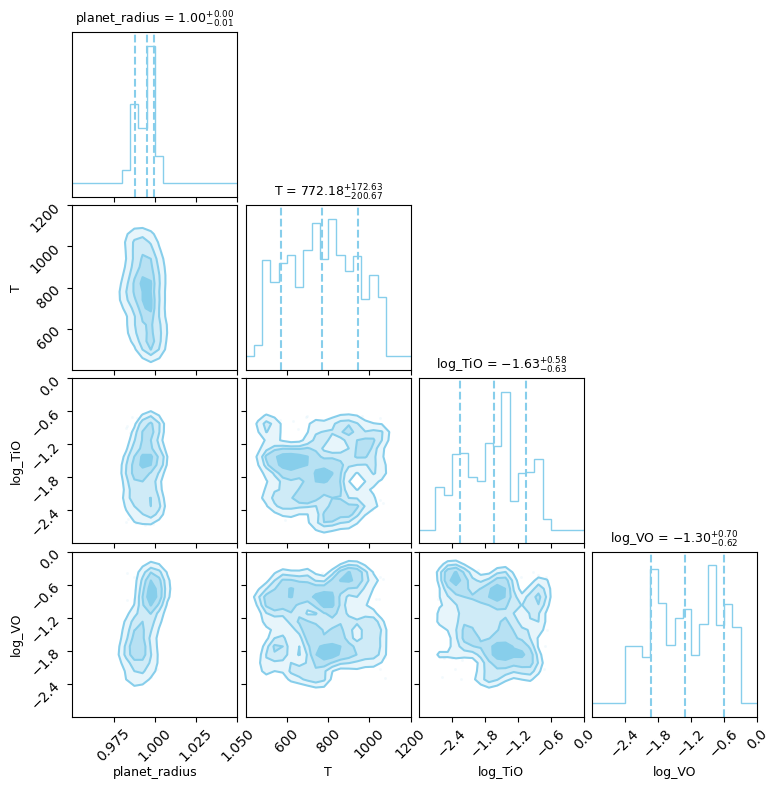

In [5]:
plot_single_retrieval()

In [6]:
real_data = pd.read_csv(DATA_FILE_PATH, sep="\t")

retrieved_data = []
valid_planet_ids = []

for planet_id in real_data.index:
    file_name = RETRIEVAL_FILE_TEMPLATE.format(planet_id=planet_id)
    
    if not os.path.exists(file_name):
        print(f"File not found for planet_id {planet_id}. Skipping.")
        continue
    
    with open(file_name, "rb") as f:
        solution = pickle.load(f)
    
    tracedata = solution['solution0']['tracedata'][:]
    latex_names = list(solution["solution0"]["fit_params"].keys())
    
    # Compute medians
    median_vals = [np.percentile(tracedata[:, j], 50) for j in range(len(latex_names))]
    
    retrieved_data.append(median_vals)
    valid_planet_ids.append(planet_id)

File not found for planet_id 87. Skipping.


In [7]:
retrieved_df = pd.DataFrame(retrieved_data, index=valid_planet_ids, columns=latex_names)
real_data_filtered = real_data.loc[valid_planet_ids].copy()

real_data_filtered_log10 = real_data_filtered.copy()
real_data_filtered_log10.iloc[:, 2:5] = np.log10(real_data_filtered_log10.iloc[:, 2:5])
real_data_filtered_log10.rename(
    columns={col: f"log10_{col}" for col in real_data_filtered_log10.columns[2:5]},
    inplace=True
)

In [8]:
suffix = "GridCV"
test_RFR_Rp = pd.read_csv(f'{BASE_DIR}/pred_res_test_pred_Rp_{suffix}.csv')
s = pd.to_numeric(test_RFR_Rp["pl_radj_test"], errors='coerce')
test_RFR_Rp_1 = test_RFR_Rp[s.between(0.8, 1, inclusive='left')].copy()

y_pred = pd.read_csv(f"{BASE_DIR}/pred_res_test_102.csv")
y_pred = y_pred.loc[:len(retrieved_data)-1, :]

model_path = f"{BASE_DIR}/GridCV_best_model_pred_Rp.pkl"
model = joblib.load(model_path)

raw_data_path = f'{BASE_DIR}/Syn102_split_raw_data_raw.pkl'
loaded_data = joblib.load(raw_data_path)

band_columns = ['U', 'B', 'V', 'R', 'I', 'u', 'g', 'r', 'i', 'z']
test_depth_df = pd.DataFrame(loaded_data['X_test'], columns=band_columns)

scaled_test = StandardScaler().fit_transform(test_depth_df)
scaled_test_df = pd.DataFrame(scaled_test, columns=test_depth_df.columns)

RFR_Rp_test = model.predict(scaled_test_df.values)

In [9]:
def plot_panel(ax, x_true_1, y_pred_1, x_true_2, y_pred_2,
               xlabel, ylabel, label1="TauREx3", label2="RFR",
               legend_loc="upper left", use_cmap_1=False, cmap_1='viridis'):
    """Helper function to plot dual-scatter comparisons with R2 scores."""
    
    # R^2 scores
    r2_1 = r2_score(x_true_1, y_pred_1) if len(x_true_1) > 1 else np.nan
    r2_2 = r2_score(x_true_2, y_pred_2) if len(x_true_2) > 1 else np.nan

    if use_cmap_1:
        scatter_1 = ax.scatter(x_true_1, y_pred_1, alpha=0.8, s=20, 
                               c=x_true_1, cmap=cmap_1, marker='o',
                               label=f"{label1} (R$^2$={r2_1:.3f})")
    else:
        scatter_1 = ax.scatter(x_true_1, y_pred_1, alpha=0.8, s=20, 
                               color="orange", marker='o',
                               label=f"{label1} (R$^2$={r2_1:.3f})")
        
    scatter_2 = ax.scatter(x_true_2, y_pred_2, alpha=0.8, s=20, 
                           color="slateblue", marker='o', 
                           label=f"{label2} (R$^2$={r2_2:.3f})")

    all_vals = np.concatenate([x_true_1, y_pred_1, x_true_2, y_pred_2]) if len(x_true_2) else np.concatenate([x_true_1, y_pred_1])
    vmin, vmax = np.min(all_vals), np.max(all_vals)
    pad = 0.05 * (vmax - vmin if vmax > vmin else 1.0)
    lo, hi = vmin - pad, vmax + pad

    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, color="black", zorder=0)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
    ax.legend(loc=legend_loc, fontsize=14, frameon=False)

    return scatter_1 if use_cmap_1 else None, r2_1, r2_2

In [11]:
mpl.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman'],
    'text.usetex'      : True,
    'font.size'        : 24,
    'font.weight'      : 'bold', 
    'axes.labelweight' : 'bold',
})

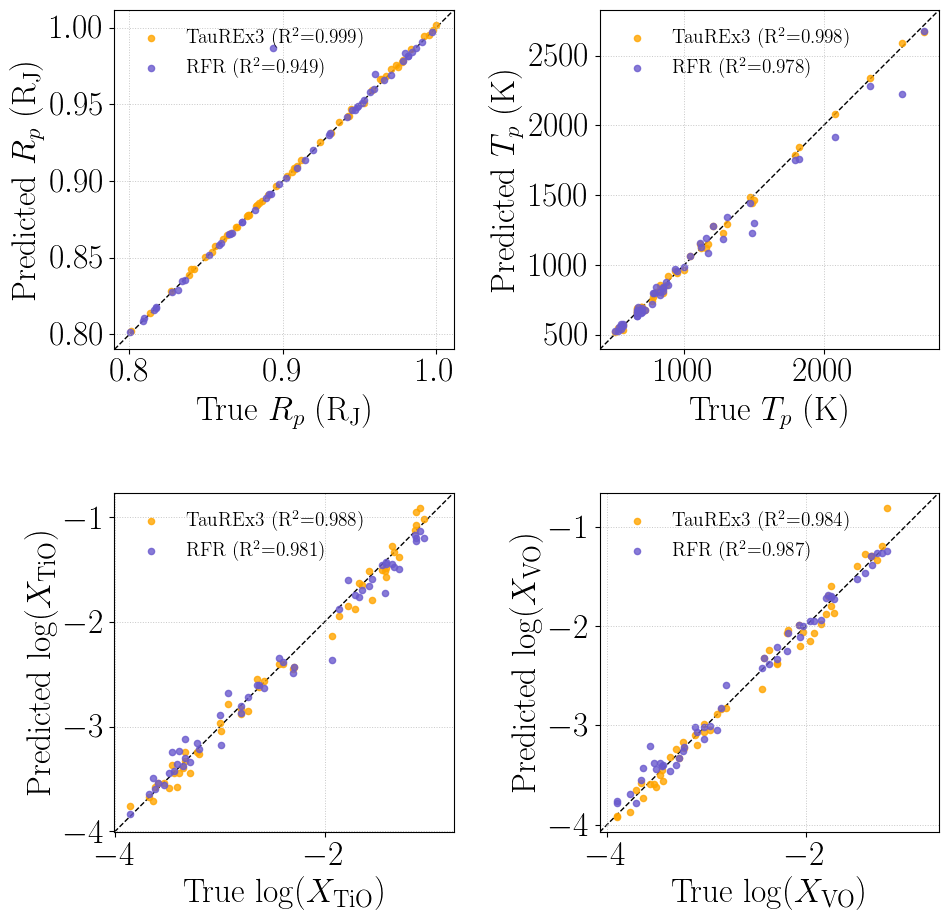

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Top Left: Rp
plot_panel(
    axes[0, 0],
    x_true_1=real_data_filtered_log10['pl_radj'].iloc[:NUM_PLANETS_TO_PLOT],
    y_pred_1=retrieved_df['planet_radius'].iloc[:NUM_PLANETS_TO_PLOT],
    x_true_2=test_RFR_Rp_1['pl_radj_test'].iloc[:NUM_PLANETS_TO_PLOT],
    y_pred_2=test_RFR_Rp_1['pl_radj_test_pred'].iloc[:NUM_PLANETS_TO_PLOT],
    xlabel=r"True $R_p\ \mathrm{(R_J)}$",
    ylabel=r"Predicted $R_p\ \mathrm{(R_J)}$"
)

# Top Right: Tp (Linear Scale)
plot_panel(
    axes[0, 1],
    x_true_1=real_data_filtered['pl_eqt'].iloc[:NUM_PLANETS_TO_PLOT],
    y_pred_1=retrieved_df['T'].iloc[:NUM_PLANETS_TO_PLOT],
    x_true_2=10**y_pred["pl_eqt_test"].iloc[:NUM_PLANETS_TO_PLOT],
    y_pred_2=10**y_pred["pl_eqt_test_pred"].iloc[:NUM_PLANETS_TO_PLOT],
    xlabel=r"True $T_p\ (\mathrm{K})$",
    ylabel=r"Predicted $T_p\ (\mathrm{K})$"
)

# Bottom Left: log10 X_TiO
plot_panel(
    axes[1, 0],
    x_true_1=real_data_filtered_log10['log10_MR_TiO'].iloc[:NUM_PLANETS_TO_PLOT],
    y_pred_1=retrieved_df['log_TiO'].iloc[:NUM_PLANETS_TO_PLOT],
    x_true_2=y_pred["mr_TiO_test"].iloc[:NUM_PLANETS_TO_PLOT],
    y_pred_2=y_pred["mr_TiO_test_pred"].iloc[:NUM_PLANETS_TO_PLOT],
    xlabel=r"True $\log(X_{\mathrm{TiO}})$",
    ylabel=r"Predicted $\log(X_{\mathrm{TiO}})$"
)

# Bottom Right: log10 X_VO
plot_panel(
    axes[1, 1],
    x_true_1=real_data_filtered_log10['log10_MR_VO'].iloc[:NUM_PLANETS_TO_PLOT],
    y_pred_1=retrieved_df['log_VO'].iloc[:NUM_PLANETS_TO_PLOT],
    x_true_2=y_pred["mr_VO_test"].iloc[:NUM_PLANETS_TO_PLOT],
    y_pred_2=y_pred["mr_VO_test_pred"].iloc[:NUM_PLANETS_TO_PLOT],
    xlabel=r"True $\log(X_{\mathrm{VO}})$",
    ylabel=r"Predicted $\log(X_{\mathrm{VO}})$"
)

plt.tight_layout(rect=(0, 0.0, 1, 1))
plt.savefig('Comparison_TauREx_RFR_102-C89_50.pdf', bbox_inches='tight')
plt.show()